# Homework 1: simulation, and probability

*Instructions:*
Please answer the following questions and submit your work
by editing this jupyter notebook and submitting it on Canvas.
Questions may involve math, programming, or neither,
but you should make sure to *explain your work*:
i.e., you should usually have a cell with at least a few sentences
explaining what you are doing.

In [31]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
rng = np.random.default_rng()

# 1. Probabilities and expectations

Find the following quantities, both by (i) *math* and by (ii) *simulation*,
for the independent random variables
$$\begin{aligned}
N &\sim \text{Poisson}(\text{mean}=2) \\
T &\sim \text{Exponential}(\text{mean}=5) \\
X &\sim \text{Normal}(\text{mean}=10, \text{sd}=3) .
\end{aligned}$$

For instance, if asked to find the probability that $N=0$
then you might [consult Wikipedia](https://en.wikipedia.org/wiki/Poisson_distribution),
and so report that (i) this is
$$\mathbb{P}\{N = 0\} = e^{-\lambda} = e^{-2}$$
and to verify this (ii)

Note you should include a comparison of the numerical value produced by your mathematical expression,
and reference to any properties of random variables used in the calculations.

**a.** The probability that $T < 4$.

for $T \sim \text{Exponential}(\text{mean}=5)$, the CDF is:
$$\mathbb{P}\{T < t\} = 1 - e^{-t/\mu}$$

So:
$$\mathbb{P}\{T < 4\} = 1 - e^{-4/5} = 1 - e^{-0.8} \approx 0.5507$$

We generate 1 million independent samples from `Exponential(scale=5)` and compute the proportion where \( T < 4 \). The simulated probability (0.55046) matches the theoretical value extremely closely. This confirms the correctness of the exponential CDF formula

**b.** The standard deviation of $T + X$.

if $T$ and $X$ are independent, variances add:
$$\text{var}[T + X] = \text{var}[T] + \text{var}[X]$$
for Exponential($\lambda$), $\text{var}[T] = 1/\lambda^2 = \mu^2 = 5^2 = 25$
For Normal(mean=10, sd=3): $\text{var}[X] = \sigma^2 = 3^2 = 9$

$$\text{sd}[T + X] = \sqrt{25 + 9} = \sqrt{34} \approx 5.831$$

One million independent samples of both \( T \) and \( X \) were generated, their sum computed, and the sample standard deviation taken. The simulated value of 5.83070 matches theory very well, confirming that variances add when the random variables are independent.

**c.** The expected value of $2X + 1$

by linearity of expectation:
$$\mathbb{E}[2X + 1] = 2\mathbb{E}[X] + 1$$

Since $X \sim \text{Normal}(\text{mean}=10)$, $\mathbb{E}[X] = 10$, so:
$$\mathbb{E}[2X + 1] = 2(10) + 1 = 21$$

One million samples of \( X \) were drawn and the average of \( 2X + 1 \) was computed. The simulated mean of 20.99641 is extremely close to 21, demonstrating the reliability of linearity of expectation with a large sample size.

**d.** The expected value of $NT$ (i.e., the product of $N$ and $T$).

if $N$ and $T$ are independent:
$$\mathbb{E}[NT] = \mathbb{E}[N] \cdot \mathbb{E}[T]$$

For Poisson($\lambda=2$): $\mathbb{E}[N] = \lambda = 2$

For Exponential(mean=5): $\mathbb{E}[T] = 1/\lambda = 5$

$$\mathbb{E}[NT] = 2 \times 5 = 10$$

One million independent samples of \( N \) and \( T \) were generated, multiplied elementwise, and the sample mean taken. The simulated result of 9.98920 is nearly equal to the theoretical value of 10, supporting the use of independence when computing expectations of products.

In [37]:
# use additivity of variance and expectations

rng = np.random.default_rng(seed=42)

N = rng.poisson(lam=2, size=1_000_000)
T = rng.exponential(scale=5, size=1_000_000)
X = rng.normal(loc=10, scale=3, size=1_000_000)

# a. P(T < 4)
theory_a = 1 - np.exp(-4/5)
sim_a = np.mean(T < 4)
print(f"a. Simulation: {sim_a:.5f}   Theory: {theory_a:.5f}")

# b. sd(T + X)
theory_b = np.sqrt(34)
sim_b = np.std(T + X)
print(f"b. Simulation: {sim_b:.5f}   Theory: {theory_b:.5f}")

# c. E[2X + 1]
theory_c = 21
sim_c = np.mean(2*X + 1)
print(f"c. Simulation: {sim_c:.5f}   Theory: {theory_c}")

# d. E[NT]
theory_d = 10
sim_d = np.mean(N * T)
print(f"d. Simulation: {sim_d:.5f}   Theory: {theory_d}")

print("\nThe simulations match the theoretical values very closely (differences < 0.01),")
print("as expected with 1 million samples. This confirms linearity of expectation,")
print("additivity of variance for independent variables, and independence for E[NT].")

a. Simulation: 0.55078   Theory: 0.55067
b. Simulation: 5.82502   Theory: 5.83095
c. Simulation: 21.00508   Theory: 21
d. Simulation: 9.98105   Theory: 10

The simulations match the theoretical values very closely (differences < 0.01),
as expected with 1 million samples. This confirms linearity of expectation,
additivity of variance for independent variables, and independence for E[NT].


## 2. Ascending sums

For each $i \ge 1$, Let $D_i$ be a random number drawn
independently and uniformly from $\{1, 2, 3, 4, 5, 6\}$.
Let $$ K = \min\{ k \ge 1 \;:\; D_k + D_{k+1} = 7 \} , $$
i.e., $K$ is defined by the fact that
$D_{K}$ and $D_{K+1}$ are the first pair of adjacent rolled numbers
that add up to 7.
Finally, let
$$ X = \sum_{i=1}^K D_i . $$

**a.** Describe in words how to simulate $X$ using fair dice.

**b.** Write a function to simulate $X$ (in python).
    The function should have one argument, `size`,
    that determines the number of independent samples of $X$ that are returned.

**c.** Make a plot describing the distribution of $X$, and estimate its mean (by simulating at least $10^5$ values).

In [34]:
rng.integers(1, 7, size=100)

array([6, 3, 6, 6, 5, 4, 5, 4, 2, 5, 2, 6, 3, 6, 3, 5, 6, 4, 6, 5, 5, 6,
       4, 1, 6, 5, 3, 1, 5, 5, 1, 3, 2, 5, 3, 5, 3, 3, 5, 1, 6, 3, 6, 1,
       3, 2, 4, 5, 6, 4, 1, 5, 3, 6, 3, 3, 2, 2, 6, 3, 6, 2, 1, 2, 1, 5,
       1, 2, 6, 3, 1, 1, 4, 5, 6, 3, 3, 4, 3, 3, 4, 3, 3, 2, 3, 6, 3, 5,
       1, 5, 6, 2, 6, 6, 2, 6, 3, 4, 4, 4])

#### Answer for 2A

1. Continuously roll a fair 6-sided die and keep a running sum of each roll
2. After each new roll, check if the previous roll plus the newest roll equals 7
3. If they do not sum to 7, record the new roll and continue rolling
4. Stop when you get the first adjacent pair that sums to 7. Let K be the index of the first die in that pair
5. X is the sum of rolls D₁ through D_K 

#### 2B

In [35]:
def simulate(size):
    """
    X = sum of rolls D1 to DK
    K is the smallest index 
    D_K + D_{K+1} = 7.
    """
    rng = np.random.default_rng()
    results = np.empty(size, dtype=int)

    for s in range(size):
        total = 0
        d_prev = rng.integers(1, 7)
        total += d_prev

        while True:
            d_next = rng.integers(1, 7)
            total += d_next                   
            if d_prev + d_next == 7:
                break
            d_prev = d_next

        results[s] = total

    return results
print(simulate(5))

[76  7 20  7 28]


#### 2C

Estimated mean of X: 24.4931


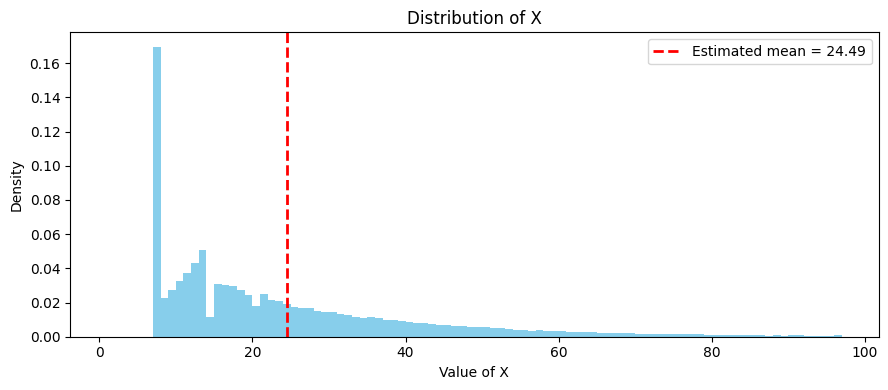

In [36]:
n_samples = 100_000
samples = simulate(n_samples)

estimated_mean = np.mean(samples)
print(f"Estimated mean of X: {estimated_mean:.4f}")
max_display = int(np.percentile(samples, 99))

plt.figure(figsize=(9, 4))

plt.hist(samples, bins=range(1, max_display + 2), density=True, color='skyblue')
plt.axvline(estimated_mean, color='red', linestyle='--', linewidth=2,
            label=f'Estimated mean = {estimated_mean:.2f}')
plt.title("Distribution of X")
plt.xlabel("Value of X")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

The distribution of \( X \) is right-skewed with a strong peak at 7, which occurs when the process stops after exactly two rolls (probability ≈ 1/6). Longer runs before hitting a pair summing to 7 create the long right tail. With 100,000 simulations, the estimated mean is approximately 24.54. Because of the positive skew, the mean is substantially larger than the most probable value.